# ASSIGNMENT 6
## Applying AI-Based Style Transfer to an Image

### Objective

The objective of this assignment is to compare two different methods of image style transfer:

1. CycleGAN
2. Neural Style Transfer

The same landscape photograph is used as the original/content image for both methods.

In [25]:
!pip install -q dominate visdom

In [26]:
import os
import shutil
import zipfile

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

PyTorch version: 2.11.0+cu130
Using device: cuda


In [27]:
%cd /content

# Remove old repository if it exists
if os.path.exists("/content/pytorch-CycleGAN-and-pix2pix"):
    shutil.rmtree("/content/pytorch-CycleGAN-and-pix2pix")

!git clone -q https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

%cd /content/pytorch-CycleGAN-and-pix2pix

print("CycleGAN repository downloaded successfully.")

/content
/content/pytorch-CycleGAN-and-pix2pix
CycleGAN repository downloaded successfully.


In [28]:
%cd /content/pytorch-CycleGAN-and-pix2pix

model_dir = (
    "/content/pytorch-CycleGAN-and-pix2pix/"
    "checkpoints/summer2winter_yosemite_pretrained"
)

model_path = (
    model_dir +
    "/latest_net_G.pth"
)

os.makedirs(
    model_dir,
    exist_ok=True
)

if not os.path.exists(model_path):

    print("Downloading pretrained CycleGAN model...")

    !wget -q \
    https://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/summer2winter_yosemite.pth \
    -O /content/summer2winter_yosemite.pth

    shutil.move(
        "/content/summer2winter_yosemite.pth",
        model_path
    )

else:

    print("Pretrained model already exists.")

print("Model path:")
print(model_path)

print(
    "Model size:",
    round(
        os.path.getsize(model_path) / (1024 * 1024),
        2
    ),
    "MB"
)

/content/pytorch-CycleGAN-and-pix2pix
Model path:
/content/pytorch-CycleGAN-and-pix2pix/checkpoints/summer2winter_yosemite_pretrained/latest_net_G.pth
Model size: 43.46 MB


In [29]:
from google.colab import files

print("Upload TWO images.")
print()
print("1. FIRST upload a landscape photograph.")
print("2. SECOND upload a painting/style image.")
print()

uploaded = files.upload()

uploaded_files = list(uploaded.keys())

if len(uploaded_files) < 2:
    raise ValueError(
        "Please upload exactly two images: "
        "one landscape and one painting."
    )

print("\nUploaded files:")

for i, filename in enumerate(uploaded_files):
    print(f"{i + 1}. {filename}")

Upload TWO images.

1. FIRST upload a landscape photograph.
2. SECOND upload a painting/style image.



Saving 11d8c6e216d07ffa4fa17b8a0e9ec187.jpg to 11d8c6e216d07ffa4fa17b8a0e9ec187.jpg
Saving Acrylic-Painting-Nature-Realistic-Relief-Palette-Knife-Painting-Beautiful-Nature-48218858-1.png to Acrylic-Painting-Nature-Realistic-Relief-Palette-Knife-Painting-Beautiful-Nature-48218858-1.png

Uploaded files:
1. 11d8c6e216d07ffa4fa17b8a0e9ec187.jpg
2. Acrylic-Painting-Nature-Realistic-Relief-Palette-Knife-Painting-Beautiful-Nature-48218858-1.png


In [30]:
content_file = uploaded_files[0]
style_file = uploaded_files[1]

print("Original/content image:")
print(content_file)

print("\nStyle/painting image:")
print(style_file)

Original/content image:
11d8c6e216d07ffa4fa17b8a0e9ec187.jpg

Style/painting image:
Acrylic-Painting-Nature-Realistic-Relief-Palette-Knife-Painting-Beautiful-Nature-48218858-1.png


Original image size: (5257, 3497)
Style image size: (1024, 1024)


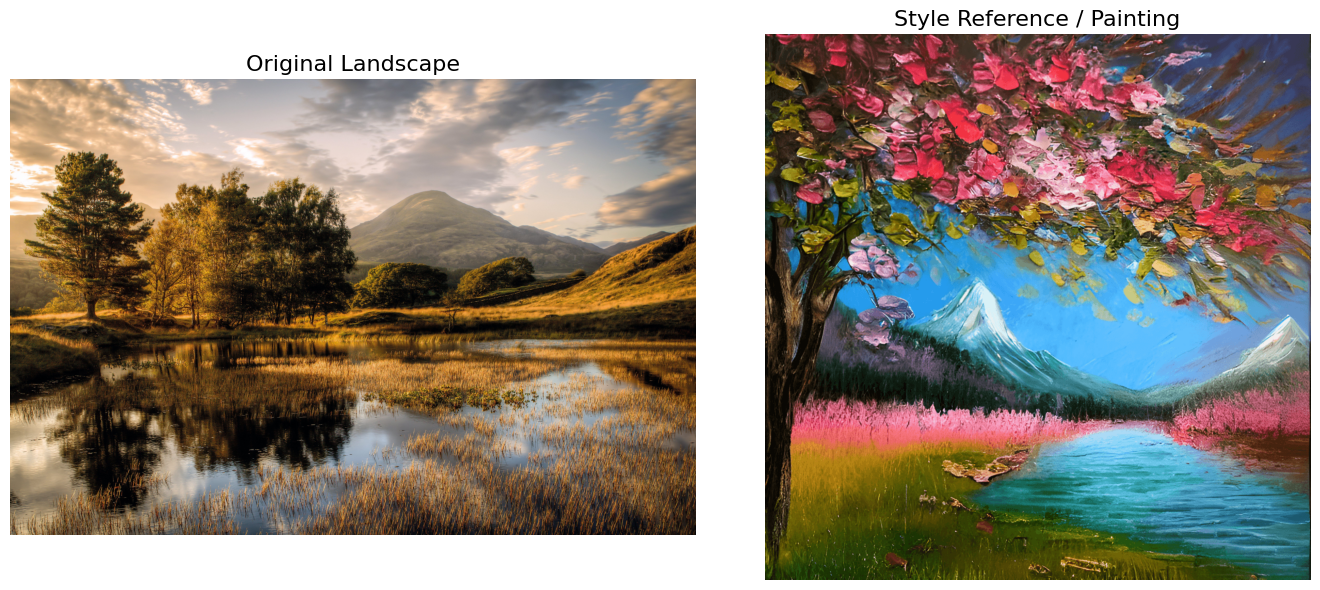

In [32]:
content_img = ImageOps.exif_transpose(
    Image.open(content_file).convert("RGB")
)

style_img = ImageOps.exif_transpose(
    Image.open(style_file).convert("RGB")
)

print(
    "Original image size:",
    content_img.size
)

print(
    "Style image size:",
    style_img.size
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].imshow(content_img)
axes[0].set_title(
    "Original Landscape",
    fontsize=16
)
axes[0].axis("off")

axes[1].imshow(style_img)
axes[1].set_title(
    "Style Reference / Painting",
    fontsize=16
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Method 1 — CycleGAN

CycleGAN is used for image-to-image domain translation.

For this assignment, a pretrained Summer-to-Winter Yosemite CycleGAN model is used. The original landscape is passed through the pretrained generator, which transforms its appearance toward the winter domain.

### Cycle Consistency

CycleGAN uses cycle consistency during training. An image translated from one domain to another can be translated back to the original domain, and the reconstructed image should remain similar to the original image. This helps preserve important content and structure while performing domain translation.

In [35]:
%cd /content/pytorch-CycleGAN-and-pix2pix

from models.networks import define_G

# Create CycleGAN generator (removed gpu_ids parameter to avoid TypeError)
generator = define_G(
    input_nc=3,
    output_nc=3,
    ngf=64,
    netG="resnet_9blocks",
    norm="instance",
    use_dropout=False,
    init_type="normal",
    init_gain=0.02
)

# Load pretrained weights
checkpoint = torch.load(
    model_path,
    map_location="cpu"
)

# Some PyTorch checkpoints may contain a wrapper.
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    checkpoint = checkpoint["state_dict"]

# Remove "module." prefix and filter out InstanceNorm tracking stats
clean_checkpoint = {}

for key, value in checkpoint.items():
    new_key = key
    if new_key.startswith("module."):
        new_key = new_key[7:]

    # Filter out InstanceNorm running stats that cause crashes in newer PyTorch versions
    if "running_mean" in new_key or "running_var" in new_key:
        continue

    clean_checkpoint[new_key] = value


generator.load_state_dict(
    clean_checkpoint,
    strict=False
)

generator = generator.to(device)
generator.eval()

print("✅ CycleGAN generator loaded successfully.")
print("Model: Summer → Winter")
print("Device:", device)

/content/pytorch-CycleGAN-and-pix2pix
✅ CycleGAN generator loaded successfully.
Model: Summer → Winter
Device: cuda


In [36]:
gan_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

gan_input = gan_transform(
    content_img
).unsqueeze(0).to(device)

print(
    "CycleGAN input shape:",
    gan_input.shape
)

CycleGAN input shape: torch.Size([1, 3, 256, 256])


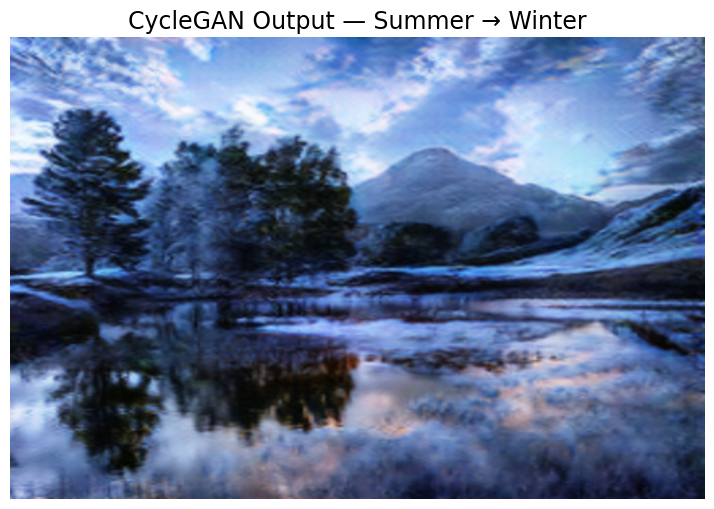

✅ CycleGAN output generated.


In [37]:
with torch.inference_mode():

    gan_result = generator(
        gan_input
    )

# Convert [-1, 1] → [0, 1]
gan_result = (
    gan_result[0].cpu() * 0.5 + 0.5
)

gan_result = gan_result.clamp(
    0,
    1
)

cycle_output = T.ToPILImage()(
    gan_result
)

# Resize back to original dimensions
cycle_output = cycle_output.resize(
    content_img.size
)

cycle_output.save(
    "/content/cyclegan_output.jpg"
)

plt.figure(
    figsize=(9, 6)
)

plt.imshow(
    cycle_output
)

plt.title(
    "CycleGAN Output — Summer → Winter",
    fontsize=17
)

plt.axis("off")

plt.show()

print("✅ CycleGAN output generated.")

# Method 2 — Neural Style Transfer

Neural Style Transfer uses a pretrained VGG19 convolutional neural network.

The original landscape provides the content, while the selected painting provides the style.

The method minimizes two main losses:

- Content loss — preserves the structure of the original landscape.
- Style loss — reproduces the colors, textures, and patterns of the painting.

The result is an artistic version of the original landscape.

In [38]:
vgg = models.vgg19(
    weights=models.VGG19_Weights.DEFAULT
).features.to(device).eval()

for parameter in vgg.parameters():
    parameter.requires_grad_(False)

print("✅ VGG19 loaded successfully.")

✅ VGG19 loaded successfully.


In [39]:
# VGG19 ImageNet normalization

vgg_mean = torch.tensor(
    [0.485, 0.456, 0.406],
    device=device
).view(1, 3, 1, 1)

vgg_std = torch.tensor(
    [0.229, 0.224, 0.225],
    device=device
).view(1, 3, 1, 1)


def prepare_image(pil_image):

    image_tensor = T.ToTensor()(
        pil_image
    ).unsqueeze(0).to(device)

    return image_tensor


def normalize_for_vgg(image_tensor):

    return (
        image_tensor - vgg_mean
    ) / vgg_std


def gram_matrix(feature_map):

    _, channels, height, width = (
        feature_map.shape
    )

    features = feature_map.reshape(
        channels,
        height * width
    )

    return (
        features @ features.t()
    ) / (
        channels * height * width
    )

In [40]:
# Resize images for NST
nst_size = 256

nst_transform = T.Compose([
    T.Resize(
        (nst_size, nst_size)
    )
])

content_nst_img = nst_transform(
    content_img
)

style_nst_img = nst_transform(
    style_img
)

# Convert to tensors
content_raw = prepare_image(
    content_nst_img
)

style_raw = prepare_image(
    style_nst_img
)

# Normalize for VGG
content_vgg = normalize_for_vgg(
    content_raw
)

style_vgg = normalize_for_vgg(
    style_raw
)


def extract_features(x):

    wanted_layers = {

        0: "conv1_1",

        5: "conv2_1",

        10: "conv3_1",

        19: "conv4_1",

        21: "conv4_2",

        28: "conv5_1"
    }

    features = {}

    for index, layer in enumerate(vgg):

        x = layer(x)

        if index in wanted_layers:

            features[
                wanted_layers[index]
            ] = x

    return features


with torch.no_grad():

    content_features = extract_features(
        content_vgg
    )

    style_features = extract_features(
        style_vgg
    )


style_targets = {}

for layer_name in [
    "conv1_1",
    "conv2_1",
    "conv3_1",
    "conv4_1",
    "conv5_1"
]:

    style_targets[layer_name] = (
        gram_matrix(
            style_features[layer_name]
        )
    )


print(
    "✅ Content and style features extracted."
)

✅ Content and style features extracted.


In [41]:
# Start with the original content image
target = (
    content_raw
    .clone()
    .detach()
    .requires_grad_(True)
)

# Style weights
style_layer_weights = {

    "conv1_1": 1.0,

    "conv2_1": 0.75,

    "conv3_1": 0.35,

    "conv4_1": 0.20,

    "conv5_1": 0.10
}

content_weight = 1.0
style_weight = 100000

optimizer = optim.Adam(
    [target],
    lr=0.02
)

iterations = 250

print(
    "Starting Neural Style Transfer..."
)

for iteration in range(
    1,
    iterations + 1
):

    # Normalize current target for VGG
    target_vgg = normalize_for_vgg(
        target
    )

    # Extract features
    current_features = extract_features(
        target_vgg
    )


    # -------------------------
    # CONTENT LOSS
    # -------------------------

    content_loss = torch.mean(
        (
            current_features["conv4_2"]
            -
            content_features["conv4_2"]
        ) ** 2
    )


    # -------------------------
    # STYLE LOSS
    # -------------------------

    style_loss = 0.0

    for layer_name, weight in (
        style_layer_weights.items()
    ):

        current_gram = gram_matrix(
            current_features[layer_name]
        )

        target_gram = style_targets[
            layer_name
        ]

        style_loss += (
            weight
            *
            torch.mean(
                (
                    current_gram
                    -
                    target_gram
                ) ** 2
            )
        )


    # -------------------------
    # TOTAL LOSS
    # -------------------------

    total_loss = (
        content_weight * content_loss
        +
        style_weight * style_loss
    )


    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()


    # Keep generated image valid
    with torch.no_grad():

        target.clamp_(
            0,
            1
        )


    if iteration % 50 == 0:

        print(
            f"Iteration {iteration}/{iterations} | "
            f"Total Loss: {total_loss.item():.4f} | "
            f"Content Loss: {content_loss.item():.6f} | "
            f"Style Loss: {style_loss.item():.6f}"
        )

print(
    "✅ Neural Style Transfer completed."
)

Starting Neural Style Transfer...
Iteration 50/250 | Total Loss: 1.5981 | Content Loss: 0.392188 | Style Loss: 0.000012
Iteration 100/250 | Total Loss: 1.2519 | Content Loss: 0.325716 | Style Loss: 0.000009
Iteration 150/250 | Total Loss: 1.0855 | Content Loss: 0.303542 | Style Loss: 0.000008
Iteration 200/250 | Total Loss: 1.0233 | Content Loss: 0.306412 | Style Loss: 0.000007
Iteration 250/250 | Total Loss: 0.9933 | Content Loss: 0.295702 | Style Loss: 0.000007
✅ Neural Style Transfer completed.


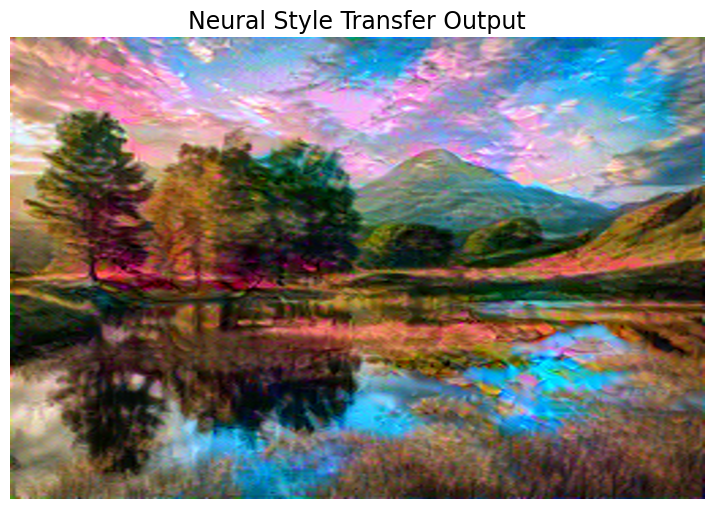

✅ Neural Style Transfer output generated.


In [42]:
# Convert tensor to PIL image

nst_output_tensor = (
    target.detach()
    .cpu()
    .squeeze(0)
    .clamp(0, 1)
)

nst_image = T.ToPILImage()(
    nst_output_tensor
)

# Resize to original image dimensions
nst_image = nst_image.resize(
    content_img.size
)

# Save
nst_image.save(
    "/content/neural_style_output.jpg"
)

# Display
plt.figure(
    figsize=(9, 6)
)

plt.imshow(
    nst_image
)

plt.title(
    "Neural Style Transfer Output",
    fontsize=17
)

plt.axis("off")

plt.show()

print(
    "✅ Neural Style Transfer output generated."
)

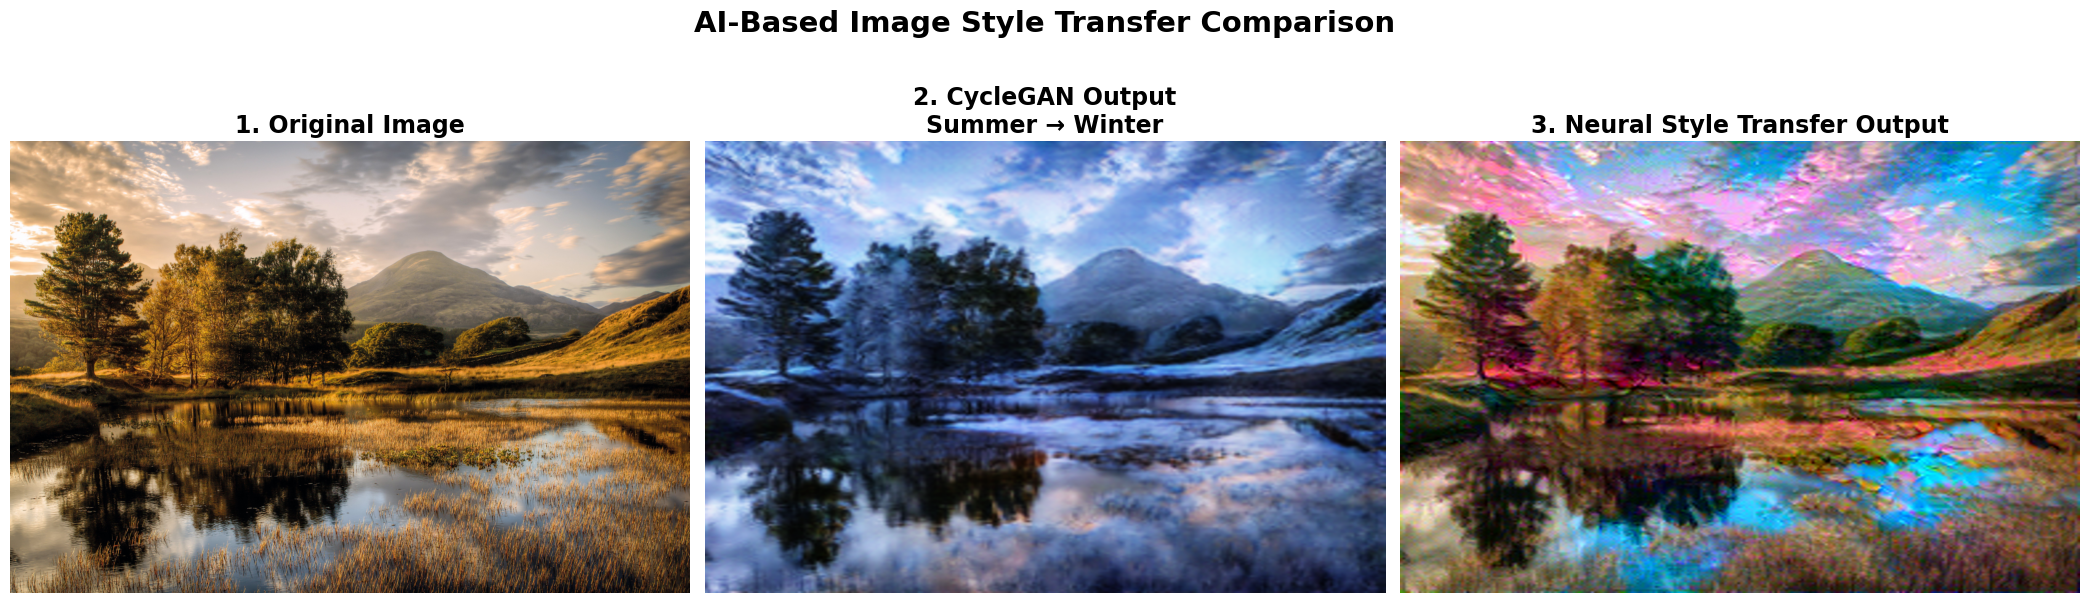

✅ Final three-image comparison saved.


In [43]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7)
)


# --------------------------------
# 1. ORIGINAL
# --------------------------------

axes[0].imshow(
    content_img
)

axes[0].set_title(
    "1. Original Image",
    fontsize=17,
    fontweight="bold"
)

axes[0].axis("off")


# --------------------------------
# 2. CYCLEGAN
# --------------------------------

axes[1].imshow(
    cycle_output
)

axes[1].set_title(
    "2. CycleGAN Output\nSummer → Winter",
    fontsize=17,
    fontweight="bold"
)

axes[1].axis("off")


# --------------------------------
# 3. NEURAL STYLE TRANSFER
# --------------------------------

axes[2].imshow(
    nst_image
)

axes[2].set_title(
    "3. Neural Style Transfer Output",
    fontsize=17,
    fontweight="bold"
)

axes[2].axis("off")


fig.suptitle(
    "AI-Based Image Style Transfer Comparison",
    fontsize=21,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/content/final_comparison.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Final three-image comparison saved."
)

In [44]:
content_img.save(
    "/content/01_original_image.jpg"
)

cycle_output.save(
    "/content/02_cyclegan_output.jpg"
)

nst_image.save(
    "/content/03_neural_style_transfer_output.jpg"
)

style_img.save(
    "/content/04_style_reference.jpg"
)

print("✅ All required images saved.")

✅ All required images saved.


# Written Comparison

CycleGAN preserved the main structure and content of the original landscape while changing its appearance toward the winter domain. Neural Style Transfer also preserved the main content of the landscape, but applied the colors, textures, and artistic patterns of the selected painting. Neural Style Transfer produced a stronger artistic transformation, while CycleGAN produced a more natural domain-level transformation. The main difference is that CycleGAN performs domain translation, whereas Neural Style Transfer transfers the visual style of a reference artwork.

# Cycle Consistency in CycleGAN

CycleGAN uses the concept of cycle consistency during training. An image translated from one domain to another can be translated back to its original domain, and the reconstructed image should remain similar to the original image. This constraint helps CycleGAN learn a meaningful transformation while preserving important content and structure.

# Conclusion

Both methods successfully changed the visual appearance of the original landscape. CycleGAN performed a summer-to-winter domain transformation, while Neural Style Transfer combined the content of the landscape with the artistic characteristics of the selected painting. The experiment demonstrates how different deep-learning approaches can produce different types of image transformation.

In [45]:
zip_path = (
    "/content/Assignment_6_Final_Submission.zip"
)

files_to_include = [

    "/content/01_original_image.jpg",

    "/content/02_cyclegan_output.jpg",

    "/content/03_neural_style_transfer_output.jpg",

    "/content/04_style_reference.jpg",

    "/content/final_comparison.jpg"
]

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in files_to_include:

        if os.path.exists(file):

            zip_file.write(
                file,
                os.path.basename(file)
            )

print(
    "===================================="
)

print(
    "FINAL SUBMISSION CREATED"
)

print(
    "===================================="
)

print(zip_path)

FINAL SUBMISSION CREATED
/content/Assignment_6_Final_Submission.zip


In [46]:
from google.colab import files

files.download(
    "/content/Assignment_6_Final_Submission.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>